In [2]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
n_community = 2
n_members = 3

tokens = []

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [208]:
class brain(nn.Module):
    def __init__(self, input_size, hidden_wake_size, hidden_sleep_size, num_layers=2, num_layers_sleep=2):
        super(brain, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_wake_size, num_layers, nonlinearity='relu', batch_first=True)
        self.sleep_layer1 = nn.Linear(input_size, hidden_sleep_size)
        self.linear_sleep = nn.Linear(hidden_sleep_size, hidden_wake_size)
        self.wake_fc = nn.Linear(hidden_wake_size, len(tokens))

    def forward(self, x, hw=None, hs=None, sleep=False):     
        if hw == None:
            out, hw = self.rnn(x)
        else:
            out, hw = self.rnn(x, hw)

        if sleep:
            hs = nn.functional.relu(
                self.sleep_layer1(x)
            )
            sleep_out = self.linear_sleep(hs)
            out = out + sleep_out
        elif hs != None:
            sleep_out = self.linear_sleep(hs)
            out = out + sleep_out

        out = self.wake_fc(out)
        
        if sleep:
            return out, hw, hs
        else:
            return out, hw

In [209]:
class network_sleep(nn.Module):
    def __init__(self, input_size, hidden_sleep_size, num_layers=1):
        super(network_sleep, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_sleep_size, num_layers, nonlinearity='relu', batch_first=True)
        self.sleep_fc = nn.Linear(hidden_sleep_size, len(tokens))

    def forward(self, x, hs=None):
        if hs == None:
            out, hs = self.rnn(x)
        else:
            out, hs = self.rnn(x, hs)

        out = self.sleep_fc(out)
        
        return out, hs

In [210]:
class compressor(nn.Module):
    def __init__(self, input_size, hidden_compressor_size, num_layers=1):
        super(compressor, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_compressor_size, num_layers, nonlinearity='relu', batch_first=True)
        self.compressor_fc = nn.Linear(hidden_compressor_size, 2)

    def forward(self, x, hc=None):
        if hc == None:
            out, hc = self.rnn(x)
        else:
            out, hc = self.rnn(x, hc)

        out = self.compressor_fc(out)
        
        return out, hc

In [211]:
def compute_geodesic(hidden1, hidden2):

    total_layers = len(hidden1)
    w = 0

    for ii in range(total_layers):
        w_ = np.array(dist( hidden1[ii], hidden2[ii], 'cosine'))
        w += w_
           
    return w[0][0]/total_layers

In [212]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [213]:
class Dataset_converter_compressor(Dataset):
    def __init__(self, data, mask):
        total_sample = len(data)
        self.X = np.zeros((total_sample-2, len(tokens)))
        self.y = np.zeros((total_sample-2, 2))
        for ii in range(total_sample-2):
            token = data[ii]
            self.X[ii, ord(token)-65] = 1 
            self.y[ii,mask[ii]] = 1
            

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [214]:
### initial training ###
total_samples = 40000
working_memory = 1
short_term_memory = 1
hidden_wake_size = 50
hidden_compressor_size = 10
hidden_sleep_size = 5
num_layers_wake = 1
num_layers_sleep = 1
output_sleep = len(tokens)
input_size = len(tokens)*working_memory
lr = 4e-4
test_acc = []

data = get_sequence(total_samples, n_community, n_members)
data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

network1 = brain(input_size, hidden_wake_size, hidden_sleep_size, num_layers_wake, num_layers_sleep)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
for X, y in train_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = network1(X)
    else:
        predicted_y, hidden = network1(X, hw=mem)
        
    loss = criterion(predicted_y[0], y)
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem=hidden.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

Iter : 1001, loss: 1.8026, accuracy: 0.2290
Iter : 2001, loss: 2.2101, accuracy: 0.3610
Iter : 3001, loss: 1.6174, accuracy: 0.4510
Iter : 4001, loss: 2.1068, accuracy: 0.6450
Iter : 5001, loss: 2.3750, accuracy: 0.7050
Iter : 6001, loss: 2.5069, accuracy: 0.7410
Iter : 7001, loss: 0.5046, accuracy: 0.7250
Iter : 8001, loss: 1.3082, accuracy: 0.7380
Iter : 9001, loss: 1.0916, accuracy: 0.7490
Iter : 10001, loss: 1.7959, accuracy: 0.7360
Iter : 11001, loss: 0.9014, accuracy: 0.7440
Iter : 12001, loss: 2.4252, accuracy: 0.7250
Iter : 13001, loss: 2.2525, accuracy: 0.7400
Iter : 14001, loss: 1.4263, accuracy: 0.7350
Iter : 15001, loss: 0.9400, accuracy: 0.7560
Iter : 16001, loss: 1.5966, accuracy: 0.7330
Iter : 17001, loss: 1.8334, accuracy: 0.7690
Iter : 18001, loss: 1.5943, accuracy: 0.7510
Iter : 19001, loss: 1.4839, accuracy: 0.7530
Iter : 20001, loss: 1.7157, accuracy: 0.7350
Iter : 21001, loss: 1.7345, accuracy: 0.7590
Iter : 22001, loss: 1.7227, accuracy: 0.7680
Iter : 23001, loss:

In [215]:
compressor_sample = 10000

data_compressor = get_sequence(compressor_sample, n_community, n_members)
data_set_compressor = Dataset_converter(data_compressor, working_memory, short_term_memory)
compressor_loader = DataLoader(data_set_compressor, batch_size=1, shuffle=False) 

ii = 0
dis = [0]
# community = ''

with torch.no_grad():
    for X, _ in compressor_loader:
        if ii==0:
            id, hw = network1(X)
            id_current = hw
            # community = tokens[torch.argmax(X[0])]
        else:
            id, hw = network1(X, hw=hw)
            id_current = hw
            if ii>=1:
                dis.append(compute_geodesic(prev_id, id_current))
                # print(dis)
                # if dis[-1] >0.407:
                #     # print(dis, tokens[torch.argmax(X[0])])
                #     community += tokens[torch.argmax(X[0])]
                    
            
        prev_id = id_current
        ii += 1

In [216]:
dis_array = np.array(dis)
threshold = np.quantile(dis_array, .6)

mask = ((dis_array>threshold)*1)

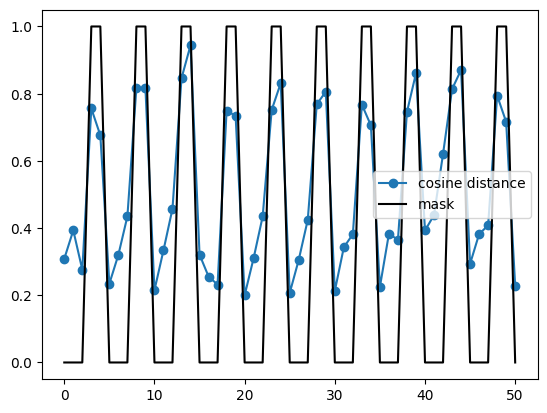

In [217]:
span = 51
plt.plot(dis[1:span+1], '-o', label='cosine distance')
plt.plot(mask[1:span+1], c='k', label = 'mask')
plt.legend()

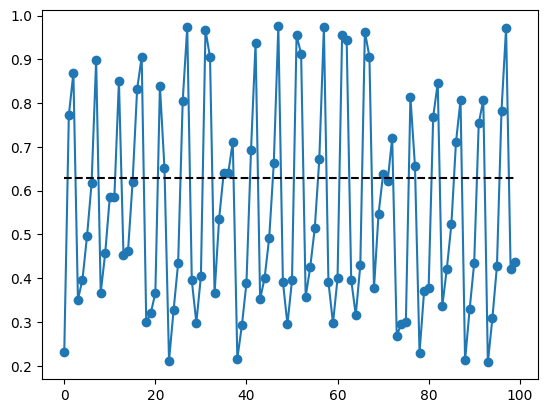

In [218]:
span = 100
plt.plot(dis[-span:], '-o')
plt.plot(np.arange(span), [threshold]*span, '--', c='k')

In [219]:
mask[-100:]

array([0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0])

In [223]:
data_set = Dataset_converter_compressor(data_compressor, mask)
compressor_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
compression = []

compressor_model = compressor(input_size, hidden_compressor_size)
optimizer = torch.optim.SGD(compressor_model.parameters(), lr=4e-3, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000, dtype=float)
for X, y in compressor_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = compressor_model(X)
    else:
        predicted_y, hidden = compressor_model(X, hc=mem)
        
    loss = criterion(predicted_y, y)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        mem = hidden.clone()

        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        if estimated_y[0]:
            compression.append((true_y[0],estimated_y[0],tokens[X.argmax(axis=1)]))
            
        total += 1
        if true_y == estimated_y:
            correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')



Iter : 1001, loss: 0.0821, accuracy: 0.8900
Iter : 2001, loss: 0.1060, accuracy: 0.9480
Iter : 3001, loss: 0.1371, accuracy: 0.9680
Iter : 4001, loss: 0.2559, accuracy: 0.9520
Iter : 5001, loss: 1.0943, accuracy: 0.9400
Iter : 6001, loss: 0.0228, accuracy: 0.9390
Iter : 7001, loss: 0.0429, accuracy: 0.9680
Iter : 8001, loss: 0.0237, accuracy: 0.9630
Iter : 9001, loss: 0.0550, accuracy: 0.9510


In [224]:
compressed_seq = ''
data = get_sequence(3000, n_community, n_members, train=False)
data_test = Dataset_converter_compressor(data, mask)
test_loader = DataLoader(data_test, batch_size=1, shuffle=False) 

total = 0
correct = np.zeros(1000, dtype=float)
for X, y in test_loader:      

    with torch.no_grad():
        if total == 0:
            predicted_y, hidden = compressor_model(X)
        else:
            predicted_y, hidden = compressor_model(X, hc=hidden)


        # if total<8:
        #     print(X)
        # print(y, predicted_y)
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        if estimated_y[0]:
            compressed_seq += tokens[X.argmax(axis=1)]
            
        total += 1

In [225]:
compressed_seq[-100:]

'GEGEGCGCGAGCGDGFGBGBGEGCGDGEGDGEGDGFGFGDGFGDGFGCGAGEGEGEGDGBGCGEGCGBGEGAGFGCGFGBGBGDGAGAGBGAGCGDGBGD'

In [226]:
sleep_samples = 200000
# compressed_seq = ''
data_sleep = get_sequence(sleep_samples, n_community, n_members)
data_set_sleep = Dataset_converter(data_sleep, working_memory, short_term_memory)

sleep_loader = DataLoader(data_set_sleep, batch_size=1, shuffle=False)
# network2 = network_sleep(input_size, hidden_sleep_size, num_layers_sleep)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
total_ = 0
hidden_s = None
correct = np.zeros(1000,dtype=float)
for X, y in sleep_loader:

    with torch.no_grad():
        if total == 0:
            predicted_y, hidden = compressor_model(X[0])
        else:
            predicted_y, hidden = compressor_model(X[0], hc=hidden)

        selection = predicted_y.argmax(axis=1)

        # if selection:
        #     sleep = True
        #     compressed_seq += data_sleep[total]
        #     X_ = y_.clone()
        #     y_ = X.clone()
        #     # print(X_,y_)
        # else:
        #     sleep = False

        
    ####################################################################
    optimizer.zero_grad()
    if selection:       
        if total == 0:
            predicted_y, hidden_w, hidden_s = network1(X, sleep=True)
        else:
            predicted_y, hidden_w, hidden_s = network1(X, hw=mem, hs=mem_, sleep=True)
    else:
        if total == 0:
            predicted_y, hidden_w = network1(X)
        else:
            predicted_y, hidden_w = network1(X, hw=mem, hs=mem_)

    loss = criterion(predicted_y[0], y)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        mem = hidden_w.clone()

        if hidden_s == None:
            mem_ = None 
        else:
            mem_ = hidden_s.clone()
            
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

            

Iter : 1001, loss: 1.7182, accuracy: 0.7580
Iter : 2001, loss: 1.6238, accuracy: 0.7530
Iter : 3001, loss: 1.3506, accuracy: 0.7450
Iter : 4001, loss: 1.8743, accuracy: 0.7500
Iter : 5001, loss: 1.5300, accuracy: 0.7470
Iter : 6001, loss: 1.3113, accuracy: 0.7370
Iter : 7001, loss: 0.8719, accuracy: 0.7630
Iter : 8001, loss: 1.2729, accuracy: 0.7450
Iter : 9001, loss: 1.8618, accuracy: 0.7570
Iter : 10001, loss: 1.0882, accuracy: 0.7550
Iter : 11001, loss: 1.0247, accuracy: 0.7390
Iter : 12001, loss: 1.4095, accuracy: 0.7420
Iter : 13001, loss: 1.2439, accuracy: 0.7640
Iter : 14001, loss: 1.6449, accuracy: 0.7370
Iter : 15001, loss: 1.2867, accuracy: 0.7550
Iter : 16001, loss: 2.0121, accuracy: 0.7580
Iter : 17001, loss: 1.4242, accuracy: 0.7450
Iter : 18001, loss: 1.7508, accuracy: 0.7550
Iter : 19001, loss: 1.4932, accuracy: 0.7330
Iter : 20001, loss: 1.3990, accuracy: 0.7460
Iter : 21001, loss: 1.9772, accuracy: 0.7590
Iter : 22001, loss: 1.3983, accuracy: 0.7690
Iter : 23001, loss:

In [116]:
mem

tensor([[[0.0000, 0.0000, 1.7212, 0.0000, 0.0000, 0.4179, 2.8194, 0.0000,
          0.5859, 1.2524, 0.7670, 1.4503, 0.0000, 0.0000, 0.0000, 0.4534,
          0.0000, 0.0000, 4.2139, 0.0000, 1.1041, 0.8926, 0.0000, 0.7370,
          0.0000, 0.0000, 1.8214, 0.0000, 0.5075, 0.0000, 0.7909, 0.0000,
          0.0000, 0.0000, 0.3189, 0.6418, 0.0000, 0.4313, 0.2366, 1.3274,
          1.3020, 0.0000, 0.4928, 0.0000, 0.7106, 0.0000, 0.0000, 2.0179,
          0.0000, 0.0000]]])

In [375]:
wake_samples = 50000
compressed_seq = ''
data_wake = get_sequence(wake_samples, n_community, n_members)
data_set_wake = Dataset_converter(data_wake, working_memory, short_term_memory)

wake_loader = DataLoader(data_set_wake, batch_size=1, shuffle=False)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
total_ = 0
sleep_mem = None
correct = np.zeros(1000,dtype=float)
for X, y in wake_loader:

    with torch.no_grad():
        if total == 0:
            prev_x = X.clone()
            predicted_y, hidden = compressor_model(X[0])
        else:
            predicted_y, hidden = compressor_model(X[0], hc=hidden)

        selection = predicted_y.argmax(axis=1)

        if selection:
            compressed_seq += data_wake[total]

            if total_ == 0:
                predicted_y_, hidden_s = network2(prev_x)
            else:
                predicted_y_, hidden_s = network2(prev_x, hidden_s)
            
            prev_x = X.clone()
            total_ += 1
    ####################################################################
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden_wake = network1(X)
    else:
        if total_ == 0:
            predicted_y, hidden_wake = network1(X, hw=mem)
        else:
            predicted_y, hidden_wake = network1(X, hw=mem, hs=hidden_s)
        
    loss = criterion(predicted_y[0], y)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        total += 1
        mem=hidden_wake.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        if true_y == estimated_y:
            # print(true_y, estimated_y)
            correct[total%1000] = 1
            # print(total, correct)
            # break
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')
            # break 
        

Iter : 1001, loss: 1.8011, accuracy: 0.2440
Iter : 2001, loss: 1.9349, accuracy: 0.2960
Iter : 3001, loss: 0.9657, accuracy: 0.4080
Iter : 4001, loss: 1.8059, accuracy: 0.5460
Iter : 5001, loss: 2.2628, accuracy: 0.6450
Iter : 6001, loss: 2.9644, accuracy: 0.6920
Iter : 7001, loss: 2.3225, accuracy: 0.6970
Iter : 8001, loss: 1.0606, accuracy: 0.7200
Iter : 9001, loss: 0.3962, accuracy: 0.7210
Iter : 10001, loss: 1.5667, accuracy: 0.7180
Iter : 11001, loss: 1.4960, accuracy: 0.7090
Iter : 12001, loss: 1.6213, accuracy: 0.7260
Iter : 13001, loss: 2.2216, accuracy: 0.7160
Iter : 14001, loss: 1.7580, accuracy: 0.7240
Iter : 15001, loss: 0.6966, accuracy: 0.7300
Iter : 16001, loss: 1.1853, accuracy: 0.7320
Iter : 17001, loss: 0.9317, accuracy: 0.7360
Iter : 18001, loss: 1.8477, accuracy: 0.7440
Iter : 19001, loss: 1.5100, accuracy: 0.7160
Iter : 20001, loss: 1.3371, accuracy: 0.7360
Iter : 21001, loss: 2.3681, accuracy: 0.7390
Iter : 22001, loss: 1.3759, accuracy: 0.7330
Iter : 23001, loss:

In [372]:
compressed_seq[-100:]

'GDGEGDGBGEGEGAGBGEGEGDGBGBGEGBGEGDGDGDGBGAGBGEGAGEGEGEGAGBGEGDGEGDGDGEGAGAGBGEGDGAGDGBGAGEGAGDGBGDGB'

In [373]:
hidden_s

tensor([[[0.9206, 0.9432, 0.8822, 0.1833, 0.0723, 1.1534, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5259, 0.0000,
          0.0000, 0.5082, 0.0000, 0.0000, 0.1975, 0.0000, 0.4137, 0.2425,
          0.0000, 0.5856, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.2948,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8018, 0.1499, 1.3644,
          0.2202, 0.7254, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3113,
          0.0000, 0.0000]]])

In [287]:
predicted_y_

tensor([[[-1.6646, -1.6087, -0.2201, -2.2594, -2.2511, -0.3330,  8.0937]]])

In [288]:
X

tensor([[[0., 0., 0., 0., 0., 1., 0.]]])

In [202]:
predicted_y

tensor([[[ 0.3027,  8.0883,  0.7656, -1.2318, -4.1577, -5.5672, -0.7501]]],
       grad_fn=<ViewBackward0>)

In [203]:
y

tensor([[0., 1., 0., 0., 0., 0., 0.]])